<a href="https://colab.research.google.com/github/Dinithiii04/AgriLak/blob/yield-component-cleanup/notebooks/NEW_regression_rnn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Paddy Yield Forecasting - Data Pre-processing & Model Implementation




In [36]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Preprocessing Yield Dataset

In [38]:
# Load the dataset
file_path = '/content/drive/MyDrive/NEW_yield_data.csv'

maha_yield = pd.read_csv(file_path)

In [39]:
display(maha_yield.head())

,District,Year,Yield,Cultivation_Season
0,PUTTALAM,1984,2158,1983-1984
1,MONARAGALA,1984,3074,1983-1984
2,JAFFNA,1984,1255,1983-1984
3,VAVUNIYA,1984,1992,1983-1984
4,MULLATIVU,1984,1153,1983-1984


In [40]:
maha_yield.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 384 entries, 0 to 383
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   District            384 non-null    object
 1   Year                384 non-null    int64 
 2   Yield               384 non-null    int64 
 3   Cultivation_Season  384 non-null    object
dtypes: int64(2), object(2)
memory usage: 12.1+ KB


In [41]:
# Drop rows from the 1983-1984 cultivation season
maha_yield = maha_yield[maha_yield['Cultivation_Season'] != '1983-1984'].reset_index(drop=True)

# Sort by District and then by Cultivation_Season
maha_yield = maha_yield.sort_values(by=['District', 'Cultivation_Season']).reset_index(drop=True)


In [42]:
# Show all rows
pd.set_option('display.max_rows', None)

In [43]:
# Display to confirm
display(maha_yield)

,District,Year,Yield,Cultivation_Season
0,AMPARA,1985,3827,1984-1985
1,AMPARA,1986,3287,1985-1986
2,AMPARA,1987,3606,1986-1987
3,AMPARA,1988,3682,1987-1988
4,AMPARA,1989,3470,1988-1989
5,AMPARA,1990,3522,1989-1990
6,AMPARA,1991,3630,1990-1991
7,AMPARA,1992,4098,1991-1992
8,AMPARA,1993,3400,1992-1993
9,AMPARA,1994,2875,1993-1994


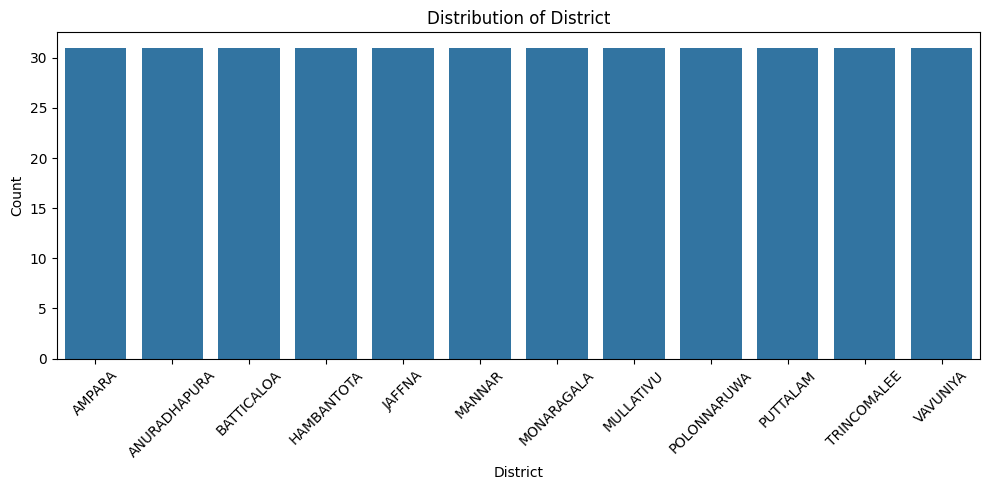

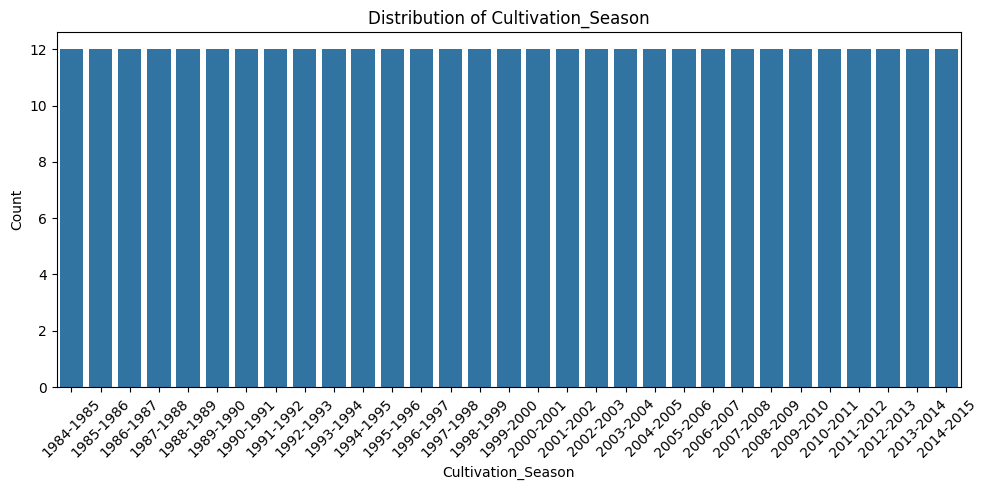

In [44]:
# Identify object (categorical) columns
object_cols = maha_yield.select_dtypes(include='object').columns

# Explore and plot each categorical column
for col in object_cols:
    # Plotting
    plt.figure(figsize=(10, 5))
    sns.countplot(data=maha_yield, x=col, order=maha_yield[col].value_counts().index)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

## Preprocessing Weather Dataset

In [45]:
weather_data = pd.read_csv('/content/drive/MyDrive/NEW_monthly_weather_data.csv')

In [46]:
display(weather_data.head())

,Year,Month,District,Tmax,SRAD,RH,Rain
0,1984,1,BATTICALOA,27.56,12.71,85.08,331.78
1,1984,1,JAFFNA,27.17,13.10,84.14,192.61
2,1984,1,MANNAR,27.97,14.18,87.13,254.00
3,1984,1,MONARAGALA,27.58,13.96,92.02,279.90
4,1984,1,MULLATIVU,26.89,13.10,84.98,266.93


In [47]:
weather_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4608 entries, 0 to 4607
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Year      4608 non-null   int64  
 1   Month     4608 non-null   int64  
 2   District  4608 non-null   object 
 3   Tmax      4608 non-null   float64
 4   SRAD      4608 non-null   float64
 5   RH        4608 non-null   float64
 6   Rain      4608 non-null   float64
dtypes: float64(4), int64(2), object(1)
memory usage: 252.1+ KB


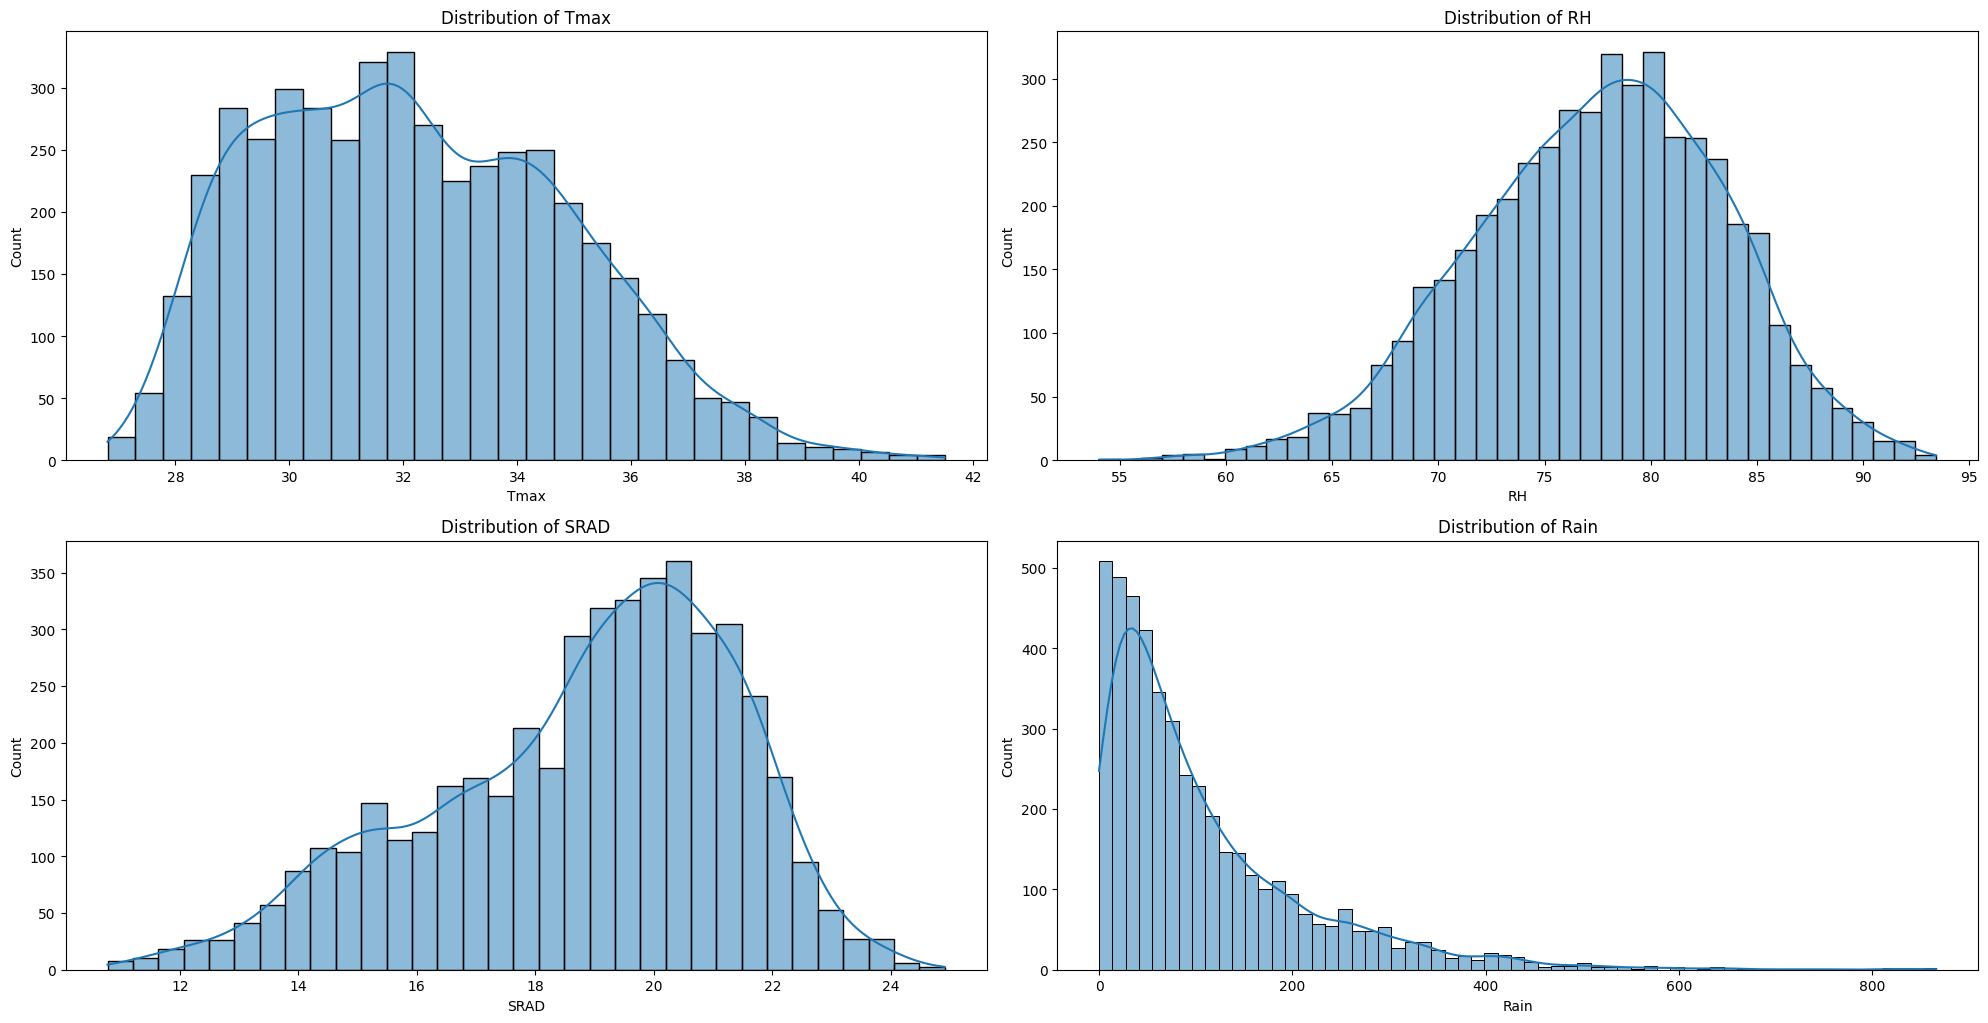

In [48]:
# Plot distributions of numeric features
numeric_cols = ['Tmax', 'RH', 'SRAD', 'Rain']

plt.figure(figsize=(20, 15))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(3, 2, i)
    sns.histplot(weather_data[col], kde=True)
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

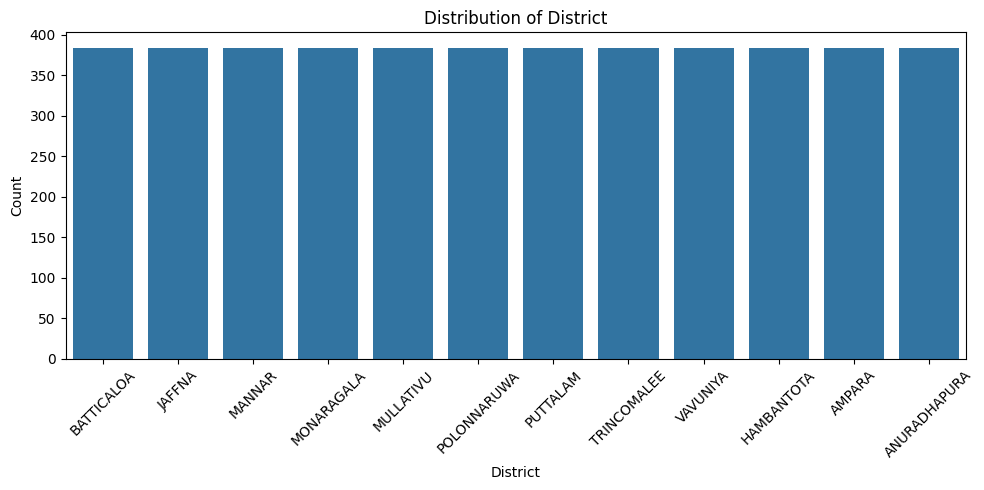

In [49]:
# Identify object (categorical) columns
object_cols = weather_data.select_dtypes(include='object').columns

# Explore and plot each categorical column
for col in object_cols:
    # Plotting
    plt.figure(figsize=(10, 5))
    sns.countplot(data=weather_data, x=col, order=weather_data[col].value_counts().index)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [51]:
def assign_cultivation_season(row):
    year = row['Year']
    month = row['Month']

    # Define valid Maha season range
    if (year == 1984 and month >= 8) or (1985 <= year <= 2014):
        if month in [8, 9, 10, 11, 12]:
            return f"{year}-{year + 1}"
    return None



In [52]:
# Apply to DataFrame
weather_data['Cultivation_Season'] = weather_data.apply(assign_cultivation_season, axis=1)

weather_data = weather_data[weather_data['Cultivation_Season'].notnull()]

# Display data
display(weather_data.head(20))

,Year,Month,District,Tmax,SRAD,RH,Rain,Cultivation_Season
84,1984,8,BATTICALOA,32.13,19.53,72.28,53.23,1984-1985
85,1984,8,JAFFNA,30.79,21.48,76.33,23.38,1984-1985
86,1984,8,MANNAR,31.07,21.30,78.19,14.91,1984-1985
87,1984,8,MONARAGALA,33.08,19.79,72.44,38.25,1984-1985
88,1984,8,MULLATIVU,31.27,21.48,77.58,30.63,1984-1985
89,1984,8,POLONNARUWA,33.45,19.53,77.00,54.60,1984-1985
90,1984,8,PUTTALAM,30.67,21.30,83.33,15.56,1984-1985
91,1984,8,TRINCOMALEE,32.42,19.40,79.22,73.03,1984-1985
92,1984,8,VAVUNIYA,33.33,21.48,78.44,31.83,1984-1985
93,1984,8,HAMBANTOTA,29.04,19.79,84.41,45.28,1984-1985


In [53]:
display(weather_data.tail(20))

,Year,Month,District,Tmax,SRAD,RH,Rain,Cultivation_Season
4444,2014,11,MULLATIVU,29.81,12.44,82.16,438.78,2014-2015
4445,2014,11,POLONNARUWA,30.84,13.67,87.47,428.72,2014-2015
4446,2014,11,PUTTALAM,30.23,13.52,86.23,293.98,2014-2015
4447,2014,11,TRINCOMALEE,30.23,13.30,83.74,438.97,2014-2015
4448,2014,11,VAVUNIYA,30.59,12.46,86.82,412.25,2014-2015
4449,2014,11,HAMBANTOTA,29.84,15.19,84.22,375.87,2014-2015
4450,2014,11,AMPARA,29.93,13.67,82.52,403.13,2014-2015
4451,2014,11,ANURADHAPURA,30.85,12.46,89.07,382.27,2014-2015
4452,2014,12,BATTICALOA,28.30,10.78,87.59,866.01,2014-2015
4453,2014,12,JAFFNA,28.19,12.41,86.05,290.38,2014-2015


In [54]:
# Correct Maha month order
maha_month_order = [8, 9, 10, 11, 12]

# Convert 'Month' column to a categorical type with the custom order
weather_data['Month'] = pd.Categorical(weather_data['Month'], categories=maha_month_order, ordered=True)

# Sort by District, Cultivation_Season, and the custom Month order
weather_data_sorted = weather_data.sort_values(by=['District', 'Cultivation_Season', 'Month']).reset_index(drop=True)


In [55]:
# Display the full sorted DataFrame
display(weather_data_sorted)


,Year,Month,District,Tmax,SRAD,RH,Rain,Cultivation_Season
0,1984,8,AMPARA,32.13,19.53,72.28,53.23,1984-1985
1,1984,9,AMPARA,33.00,19.81,71.84,228.09,1984-1985
2,1984,10,AMPARA,31.03,18.66,76.50,151.14,1984-1985
3,1984,11,AMPARA,28.71,16.61,83.00,294.75,1984-1985
4,1984,12,AMPARA,28.19,15.23,82.81,76.80,1984-1985
5,1985,8,AMPARA,33.29,19.11,67.45,52.46,1985-1986
6,1985,9,AMPARA,33.63,19.80,68.98,115.23,1985-1986
7,1985,10,AMPARA,31.84,18.62,76.08,170.00,1985-1986
8,1985,11,AMPARA,29.10,16.16,80.48,208.12,1985-1986
9,1985,12,AMPARA,27.77,14.70,83.71,104.69,1985-1986


In [56]:
weather_data_sorted.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1860 entries, 0 to 1859
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   Year                1860 non-null   int64   
 1   Month               1860 non-null   category
 2   District            1860 non-null   object  
 3   Tmax                1860 non-null   float64 
 4   SRAD                1860 non-null   float64 
 5   RH                  1860 non-null   float64 
 6   Rain                1860 non-null   float64 
 7   Cultivation_Season  1860 non-null   object  
dtypes: category(1), float64(4), int64(1), object(2)
memory usage: 103.9+ KB


In [57]:
weather_df = weather_data_sorted.copy()
yield_df = maha_yield.copy()

## Model Implementation

In [58]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense

In [59]:
# Define feature columns and month order
features = ['Tmax', 'SRAD', 'RH', 'Rain']
maha_month_order = [8, 9, 10, 11, 12]

# Convert Month column to ordered categorical
weather_df['Month'] = pd.Categorical(
    weather_df['Month'],
    categories=maha_month_order,
    ordered=True
)

# set index
yield_df.set_index(['District', 'Cultivation_Season'], inplace=True)

# Build sequences
X = []
y = []
X_keys = []

# Group weather data by District and Cultivation_Season
grouped = weather_df.groupby(['District', 'Cultivation_Season'])

for (district, season), group in grouped:
    group = group.sort_values(by='Month')
    if len(group) == 5:  # keep only complete Maha seasons
        sequence = group[features].values
        X.append(sequence)
        X_keys.append((district, season))

        # Get corresponding yield
        if (district, season) in yield_df.index:
            y.append(yield_df.loc[(district, season), 'Yield'])

# Convert to NumPy arrays
X = np.array(X)
y = np.array(y)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Sample key (district, season):", X_keys[0])


X shape: (372, 5, 4)
y shape: (372,)
Sample key (district, season): ('AMPARA', '1984-1985')


In [60]:
# Check the first input sequence
sample_index = 0
sample_input = X[sample_index]

print(f"Shape: {sample_input.shape}")
print(f"District and Season: {X_keys[sample_index]}")
print("\nSample Input Sequence (Aug → Jan):\n")
print(pd.DataFrame(sample_input, columns=features, index=[8, 9, 10, 11, 12]))


Shape: (5, 4)
District and Season: ('AMPARA', '1984-1985')

Sample Input Sequence (Aug → Jan):

     Tmax   SRAD     RH    Rain
8   32.13  19.53  72.28   53.23
9   33.00  19.81  71.84  228.09
10  31.03  18.66  76.50  151.14
11  28.71  16.61  83.00  294.75
12  28.19  15.23  82.81   76.80


In [62]:
X_train, X_test, y_train, y_test, keys_train, keys_test = train_test_split(
    X, y, X_keys, test_size=0.2, random_state=42
)

In [63]:
from sklearn.preprocessing import MinMaxScaler

# Flatten to 2D
X_train_2d = X_train.reshape(-1, X_train.shape[2])
X_test_2d = X_test.reshape(-1, X_test.shape[2])

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train_2d)
X_test_scaled = scaler.transform(X_test_2d)

# Reshape back
X_train_scaled = X_train_scaled.reshape(X_train.shape)
X_test_scaled = X_test_scaled.reshape(X_test.shape)

In [64]:
model = Sequential()
model.add(SimpleRNN(16, input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mse')

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [65]:
history = model.fit(
    X_train_scaled, y_train,
    validation_split=0.1,
    epochs=20,
    batch_size=16,
    verbose=1
)


Epoch 1/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - loss: 14258551.0000 - val_loss: 15171364.0000
Epoch 2/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 14155517.0000 - val_loss: 15164875.0000
Epoch 3/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 14315925.0000 - val_loss: 15159294.0000
Epoch 4/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 14766304.0000 - val_loss: 15154155.0000
Epoch 5/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 13907324.0000 - val_loss: 15149232.0000
Epoch 6/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 14456783.0000 - val_loss: 15144234.0000
Epoch 7/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 13820179.0000 - val_loss: 15139102.0000
Epoch 8/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 14330620.0000 - val_loss: 15134368.0000
Epoch 9/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 14130721.0000 - val_loss: 15130204.0000
Epoch 10/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 14750999.0000 - val_loss: 15126470.0000
Epoch 11/20
17/17

In [68]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Predictions on train and test sets
y_train_pred = model.predict(X_train_scaled)
y_test_pred = model.predict(X_test_scaled)

# Compute metrics for Training Set
train_mae = mean_absolute_error(y_train, y_train_pred)
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
train_r2 = r2_score(y_train, y_train_pred)

# Compute metrics for Test Set
test_mae = mean_absolute_error(y_test, y_test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
test_r2 = r2_score(y_test, y_test_pred)

# Print results
print(f"Training Performance:")
print(f"Train R² Score: {train_r2:.4f}")
print(f"Train RMSE: {train_rmse:.2f}")
print(f"Train MAE: {train_mae:.2f}")

print(f"\nTesting Performance:")
print(f"Test R² Score: {test_r2:.4f}")
print(f"Test RMSE: {test_rmse:.2f}")
print(f"Test MAE: {test_mae:.2f}")


10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
Training Performance:
Train R² Score: -16.1601
Train RMSE: 3764.84
Train MAE: 3653.49

Testing Performance:
Test R² Score: -11.8062
Test RMSE: 3624.25
Test MAE: 3479.87
